# Carry and Volatility: Model Extensions

This week we tested four extensions to the replicated neural network (NN) for estimating **same-week Managed Money (MM) position changes** in six energy markets: carry inside the network, carry as an error correction, volatility scaling, and scaling plus carry correction.

**The combination gives the highest R² in this historical comparison:** **48.40%**, versus **44.90%** for the original NN. On the same 2017–2025 observations, mean absolute error (MAE) falls from **10,794 to 10,499 contracts**, a **2.7%** reduction. Carry adds 1.12 percentage points of R² beyond the volatility model.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'working_ideas' else Path.cwd()
PROJECT_ROOT = REPO_ROOT / 'paper_replication'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from paper_replication.config import HORIZONS, MARKETS, ReplicationConfig
from paper_replication.data import load_inputs
from paper_replication.evaluate import run_replication
from paper_replication.model import SharedMomentumNetwork, PaperAdam, reaction, align_bias_state

OUTPUT = PROJECT_ROOT / 'outputs' / 'carry_volatility'
OUTPUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(1)
config = ReplicationConfig(data_dir=PROJECT_ROOT / 'data_required', basis='futures_only',
                           train_weeks=104, seed=7)
HEAD_PENALTY = 0.1
COMMON_START = pd.Timestamp('2017-01-01')
KEYS = ['report_week_tuesday', 'market']
COLORS = {'Original NN': '#60666c', 'Direct carry': '#b7782c',
          'Carry correction': '#277f8e', 'Risk scaling': '#596eaf',
          'Risk + carry': '#96587e'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

## Common setup

We begin rolling fits in 2015. Each NN uses the preceding 104 weeks, with 1,024 epochs at the first fit and 36 thereafter, starting each new fit from the previous weights. The corrections need 104 earlier out-of-sample errors, so we compare all models on the same 2,820 market-week observations from 2017–2025.

We estimate **same-week position changes using current prices**, not future returns:

$$\widehat{\Delta MM}_{m,t}=s_{m,t}\left[\hat y_{m,t}(\theta_t)-\hat y_{m,t-1}(\theta_t)\right].$$

$\hat y$ is a normalized position level; $s$ is the lagged position scale (`mm_std_lag`), which converts normalized changes to contracts. Both endpoints use the same fitted model and final training bias. R² is measured against predicting no position change; directional accuracy measures how often the sign is correct.

In [2]:
reference = run_replication(config, progress=False)
baseline = reference['predictions'].copy()
prices, meta, _ = load_inputs(config)
panel = reference['weekly_panel'].merge(
    reference['daily_features'][['market', 'date', 'pnl_vol']],
    left_on=['market', 'feature_date'], right_on=['market', 'date'],
    how='left', validate='one_to_one')
complete = panel.groupby('report_week_tuesday')['market'].nunique().eq(len(MARKETS))
weeks = sorted(complete[complete].index)
rows = panel.set_index(KEYS).reindex(pd.MultiIndex.from_product([weeks, MARKETS], names=KEYS))
x = torch.tensor(rows[[f'x_{h}' for h in HORIZONS]].to_numpy().reshape(-1, 6, 50), dtype=torch.float32)
y = torch.tensor(rows['y'].to_numpy().reshape(-1, 6), dtype=torch.float32)
vol_values = rows['pnl_vol'].to_numpy().reshape(-1, 6)
evaluation_weeks = set(panel.loc[panel['panel_date'].between(
    config.evaluation_start, config.evaluation_end), 'report_week_tuesday'])

## Carry measure

Following the futures-basis idea in [Koijen et al. (2018)](https://www.aqr.com/Insights/Research/Journal-Article/Carry), we compare the held contract with the same delivery month one year later:

$$c_{m,t}=\frac{F^{held}_{m,t}-F^{next\ year}_{m,t}}{\tau_{m,t}\nu_{m,t}},\qquad
\bar c_{m,t}=\frac14\sum_{j=0}^{3}c_{m,t-j}.$$

$\tau$ is the expiry gap in years and $\nu$ is annualized price-change volatility from earlier observations. Positive carry means backwardation; matching delivery months reduces seasonal mismatch. For each fit, $z$ is the four-week average standardized on the preceding 104 weeks and clipped to $[-3,3]$.

We use the annual spread and four-week smoothing for this test.

In [3]:
DEFAULT_FEATURE = 'annual_carry_smooth4'


def standardize_window(raw, train_weeks=104, clip=3.0):
    """Scale train+current rows using only the preceding training rows."""
    raw = np.asarray(raw, dtype=float)
    missing = ~np.isfinite(raw)
    median = np.nanmedian(np.where(missing[:-1], np.nan, raw[:-1]), axis=0)
    filled = np.where(missing, median[None, :], raw)
    mean, std = filled[:-1].mean(axis=0), filled[:-1].std(axis=0)
    z = np.clip((filled-mean)/np.maximum(std, 1e-6), -clip, clip)
    return dict(z=z, mean=mean, std=std, median=median, current_missing=missing[-1])


def build_carry_features(daily, panel, prices, meta, smoothing_weeks=4):
    """Map actual annual contract pairs, then take a trailing four-report mean."""
    frames = []
    for market, group in daily.groupby('market', sort=True):
        g = group.sort_values('date').reset_index(drop=True)
        m = meta.loc[meta.market.eq(market)].sort_values('LAST_TRADEABLE_DT').reset_index(drop=True)
        front = np.searchsorted(m.LAST_TRADEABLE_DT.to_numpy(), g.date.to_numpy(), side='left')
        held_key = g.contract_key.to_numpy(dtype=int)
        held = m.iloc[held_key].reset_index(drop=True)
        lookup = {(int(r.maturity_year), int(r.maturity_month)): i for i,r in m.iterrows()}
        far_key = np.array([lookup[(int(r.maturity_year)+1,int(r.maturity_month))] for _,r in held.iterrows()])
        far = m.iloc[far_key].reset_index(drop=True)
        near_generic, far_generic = held_key-front+1, far_key-front+1
        q = prices.loc[prices.market.eq(market)].set_index(['date','nearby'])
        # Strict settlement quotes: missing carry is imputed only inside a later training window.
        near_px = q.PX_SETTLE.reindex(pd.MultiIndex.from_arrays([g.date,near_generic])).to_numpy()
        far_px = q.PX_SETTLE.reindex(pd.MultiIndex.from_arrays([g.date,far_generic])).to_numpy()
        gap = (far.LAST_TRADEABLE_DT-held.LAST_TRADEABLE_DT).dt.days.to_numpy()/365.25
        vol = g.pnl_vol.to_numpy(dtype=float)
        carry = np.divide(near_px-far_px,gap*vol,out=np.full(len(g),np.nan),where=np.isfinite(vol)&(vol>0))
        frames.append(pd.DataFrame(dict(date=g.date, market=market, annual_carry=carry)))
    curve = pd.concat(frames,ignore_index=True)
    rows = []
    for market,group in panel.groupby('market',sort=True):
        left = group[['report_week_tuesday','report_date','market']].sort_values('report_date')
        right = curve.loc[curve.market.eq(market),['date','annual_carry']].sort_values('date')
        w = pd.merge_asof(left,right,left_on='report_date',right_on='date',direction='backward')
        w = w.rename(columns={'date':'carry_feature_date'})
        w[DEFAULT_FEATURE] = w.annual_carry.rolling(4,min_periods=4).mean()
        rows.append(w)
    weekly = pd.concat(rows,ignore_index=True).sort_values(KEYS).reset_index(drop=True)
    return dict(weekly=weekly)

In [4]:
carry_data = build_carry_features(reference['daily_features'], panel, prices, meta)
carry_features = carry_data['weekly']
carry_values = carry_features.set_index(KEYS).reindex(rows.index)[DEFAULT_FEATURE].to_numpy().reshape(-1, 6)

## Model helpers

For the joint models, we retain the original NN loss and add $0.1\,\mathrm{mean}(\beta_m^2)$ for carry or $0.1\alpha^2$ for volatility scaling. We use the original initialization for both models, then update them weekly.

In [5]:
class ExtendedNetwork(SharedMomentumNetwork):
    def __init__(self, mode):
        super().__init__(MARKETS, HORIZONS, config.train_weeks, config.seed)
        self.mode = mode
        if mode == 'carry':
            self.beta = nn.Parameter(torch.zeros(len(MARKETS)))
        elif mode == 'risk':
            self.alpha = nn.Parameter(torch.zeros(1))
        else:
            raise ValueError(mode)

    def predict(self, x, feature, bias_indices=None):
        latent = reaction(torch.einsum('wmh,kh->wmk', x, self.shared_weights))
        trend = torch.einsum('wmk,mk->wm', latent, self.market_weights)
        if bias_indices is None and x.shape[0] == self.bias.shape[1]:
            bias = self.bias.T
        elif bias_indices is None:
            bias = self.bias[:, -1].expand(x.shape[0], -1)
        else:
            bias = self.bias[:, bias_indices].T
        if self.mode == 'carry':
            estimate = bias + trend + self.beta * feature
        else:
            scale = torch.exp(-self.alpha * feature)
            estimate = bias + scale * trend
        return estimate, trend, bias

    def loss(self, x, y, feature):
        estimate, _, _ = self.predict(x, feature)
        penalty = self.beta if self.mode == 'carry' else self.alpha
        return ((y - estimate).square().mean()
                + config.lambda_w * self.shared_weights.abs().sum()
                + config.lambda_bias * (self.bias[:, 1:] - self.bias[:, :-1]).square().sum()
                + HEAD_PENALTY * penalty.square().mean())


def run_extension(mode):
    forecasts, previous_state, previous_dates = [], None, None
    for i, week in enumerate(weeks):
        if i < config.train_weeks or week not in evaluation_weeks:
            continue
        start = i - config.train_weeks
        train_dates = weeks[start:i]
        if mode == 'carry':
            # One set of training statistics for both prediction endpoints.
            feature = standardize_window(carry_values[start:i + 1])['z']
        else:
            reference_vol = np.median(vol_values[start:i], axis=0)
            feature = np.log(vol_values[start:i + 1] / reference_vol)
        feature = torch.tensor(feature, dtype=torch.float32)
        model = ExtendedNetwork(mode)
        if previous_state is not None:
            model.load_state_dict(align_bias_state(previous_state, previous_dates, train_dates))
        optimizer = PaperAdam(model.parameters(), lr=config.learning_rate,
                              betas=(config.adam_beta1, config.adam_beta2), eps=config.adam_epsilon)
        epochs = config.first_epochs if previous_state is None else config.rolling_epochs
        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)
            model.loss(x[start:i], y[start:i], feature[:-1]).backward()
            optimizer.step()
            if mode == 'risk':
                with torch.no_grad():
                    model.alpha.clamp_(0, 1)
        previous_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        previous_dates = train_dates
        with torch.no_grad():
            current, trend, bias = model.predict(x[i:i + 1], feature[-1:])
            prior, prior_trend, prior_bias = model.predict(
                x[i - 1:i], feature[-2:-1], bias_indices=[config.train_weeks - 1])
        out = rows.loc[[week], ['report_date', 'panel_date', 'mm_std_lag',
                                'actual_change', 'previous_report_week']].reset_index()
        sigma = out['mm_std_lag'].to_numpy()
        out['predicted_change'] = sigma * (current.numpy()[0] - prior.numpy()[0])
        if mode == 'carry':
            out['beta'] = model.beta.detach().numpy()
        else:
            out['alpha'] = model.alpha.item()
            out['risk_multiplier'] = np.exp(-model.alpha.item() * feature[-1].numpy())
            # Diagnostic only: keep the fitted weights and remove the gate at inference.
            out['gate_off_change'] = sigma * (
                (bias + trend).detach().numpy()[0] - (prior_bias + prior_trend).detach().numpy()[0])
        forecasts.append(out)
    return pd.concat(forecasts, ignore_index=True)

In [6]:
def score(frame):
    actual, predicted = frame['actual_change'].to_numpy(), frame['predicted_change'].to_numpy()
    return pd.Series({'R² (%)': 100 * (1 - np.sum((actual - predicted)**2) / np.sum(actual**2)),
                      'Direction (%)': 100 * np.mean(np.sign(actual) == np.sign(predicted)),
                      'MAE (contracts)': np.mean(np.abs(actual - predicted)),
                      'Observations': len(frame)})


def common_sample(frame):
    return frame.loc[frame['panel_date'].between(COMMON_START, config.evaluation_end)].copy()


def paired_summary(candidate, parent, candidate_name, parent_name='Original NN'):
    a, b = common_sample(candidate).set_index(KEYS), common_sample(parent).set_index(KEYS)
    a, b = a.sort_index(), b.sort_index()
    table = pd.DataFrame({parent_name: score(b), candidate_name: score(a)}).T
    table['ΔR² (pp)'] = table['R² (%)'] - score(b)['R² (%)']
    return table


def annual_scores(frame):
    frame = common_sample(frame)
    return pd.DataFrame({year: score(group) for year, group in
                         frame.groupby(frame['panel_date'].dt.year)}).T


def annual_comparison(candidate, parent, candidate_name, parent_name='Original NN'):
    a, b = annual_scores(candidate), annual_scores(parent)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, title in zip(axes, ['R² (%)', 'Direction (%)'],
                                 ['Out-of-sample R²', 'Directional accuracy']):
        ax.plot(b.index, b[metric], marker='o', color=COLORS[parent_name], label=parent_name)
        ax.plot(a.index, a[metric], marker='s', color=COLORS[candidate_name], label=candidate_name)
        ax.set(title=title, xlabel='Year', ylabel='Percent', xticks=a.index)
        ax.grid(alpha=.25)
        ax.legend()
    fig.suptitle(f'{candidate_name}: annual position-change estimates, 2017–2025')
    fig.tight_layout()
    fig.savefig(OUTPUT / f"{candidate_name.lower().replace(' ', '_')}_annual.png", dpi=160)
    plt.show()

## 1. Carry inside the network

Backwardation may support a larger long position than momentum alone suggests. We fit one carry coefficient per market jointly with the trend weights:

$$\hat y_{m,t}=b_{m,t}+T_{m,t}+\beta_m z_{m,t}.$$

$T$ is the original three-factor trend component and $b$ is its bias. The carry coefficient can have either sign.

,R² (%),Direction (%),MAE (contracts),ΔR² (pp)
Original NN,44.90,72.70,10793.88,0.00
Direct carry,46.93,73.48,10635.00,2.03


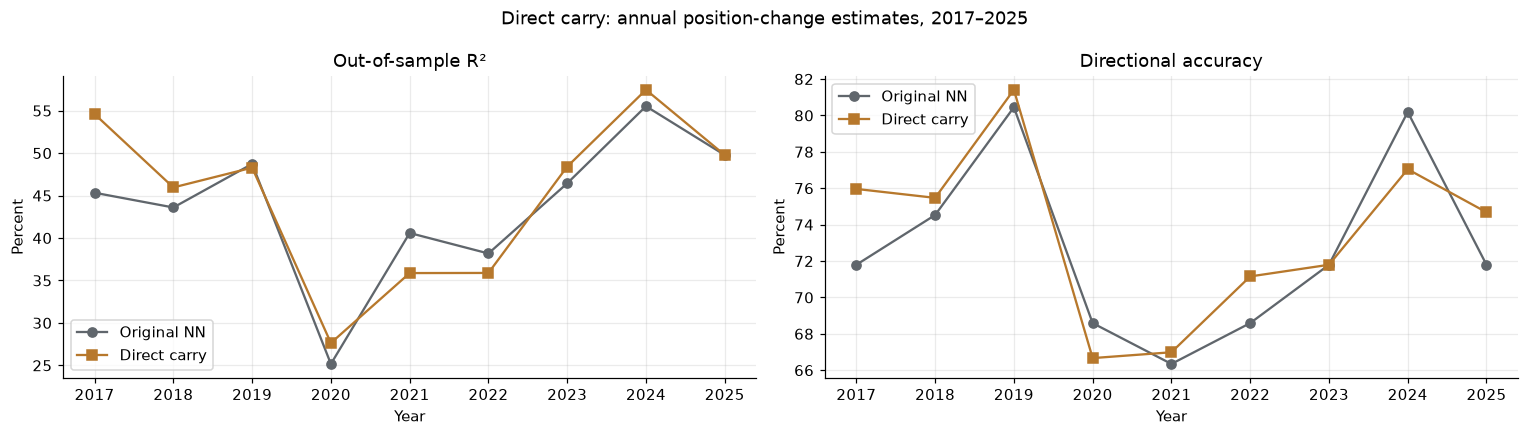

In [7]:
direct = run_extension('carry')
display(paired_summary(direct, baseline, 'Direct carry').drop(columns='Observations').round(2))
annual_comparison(direct, baseline, 'Direct carry')

R² increases to **46.93%**, a gain of 2.03 percentage points; directional accuracy rises from 72.70% to 73.48%. The gain varies by year: direct carry is slightly worse than the original NN over 2020–2022 as a whole.

## 2. Carry as an error correction

We keep the original NN forecasts fixed and use changes in carry to explain their errors:

$$\widehat{\Delta MM}^{corr}_{m,t}=\widehat{\Delta MM}^{NN}_{m,t}+s_{m,t}\gamma_{m,t}\Delta z_{m,t}.$$

For each market, we fit $\gamma$ to the previous 104 errors divided by their position scales, using ridge penalty 0.1. Each $\Delta z$ uses the same historical scaler at both endpoints. This fits weekly errors rather than position levels.

In [8]:
def build_carry_design(predictions,features,complete_dates,feature_col=DEFAULT_FEATURE,train_weeks=104,clip=3.,markets=MARKETS):
    """Freeze each carry change using its own date's historical endpoint scaler."""
    dates = pd.DatetimeIndex(complete_dates).sort_values()
    raw = features.pivot(index='report_week_tuesday',columns='market',values=feature_col).reindex(index=dates,columns=markets)
    rows = []
    for date,group in predictions.groupby('report_week_tuesday',sort=True):
        i = dates.get_loc(date)
        if i < train_weeks:
            continue
        g = group.set_index('market').reindex(markets)
        s = standardize_window(raw.iloc[i-train_weeks:i+1].to_numpy(),train_weeks,clip)
        out = g.reset_index().copy()
        out['carry_delta_z'] = s['z'][-1]-s['z'][-2]
        rows.append(out)
    design = pd.concat(rows,ignore_index=True).sort_values(KEYS).reset_index(drop=True)
    return design


def calibrate_carry_design(design,train_weeks=104,penalty=.1):
    """Fit market-specific ridge coefficients on prior genuine OOS errors only."""
    d = design.sort_values(KEYS).copy()
    d['normalized_oos_residual'] = (d.actual_change-d.predicted_change)/d.mm_std_lag
    weeks = pd.DatetimeIndex(sorted(d.report_week_tuesday.unique()))
    rows = []
    for i,date in enumerate(weeks):
        if i < train_weeks:
            continue
        hist = d.loc[d.report_week_tuesday.isin(weeks[i-train_weeks:i])]
        cur = d.loc[d.report_week_tuesday.eq(date)].copy()
        coefs = {}
        for market,g in hist.groupby('market'):
            x,r = g.carry_delta_z.to_numpy(),g.normalized_oos_residual.to_numpy()
            coefs[market] = float(np.dot(x,r)/(np.dot(x,x)+len(x)*penalty))
        cur['carry_head_coef'] = cur.market.map(coefs)
        cur['base_prediction'] = cur.predicted_change
        cur['carry_correction'] = cur.mm_std_lag*cur.carry_head_coef*cur.carry_delta_z
        cur['predicted_change'] = cur.base_prediction+cur.carry_correction
        rows.append(cur)
    return pd.concat(rows,ignore_index=True)


def carry_residual_head(predictions,features,complete_dates,feature_col=DEFAULT_FEATURE,train_weeks=104,penalty=.1,clip=3.,markets=MARKETS):
    """Calibrate against the supplied model: use risk predictions for the combination."""
    design = build_carry_design(predictions,features,complete_dates,feature_col,train_weeks,clip,markets)
    return calibrate_carry_design(design,train_weeks,penalty),design

,R² (%),Direction (%),MAE (contracts),ΔR² (pp)
Original NN,44.90,72.7,10793.88,0.00
Carry correction,46.02,73.4,10707.25,1.12


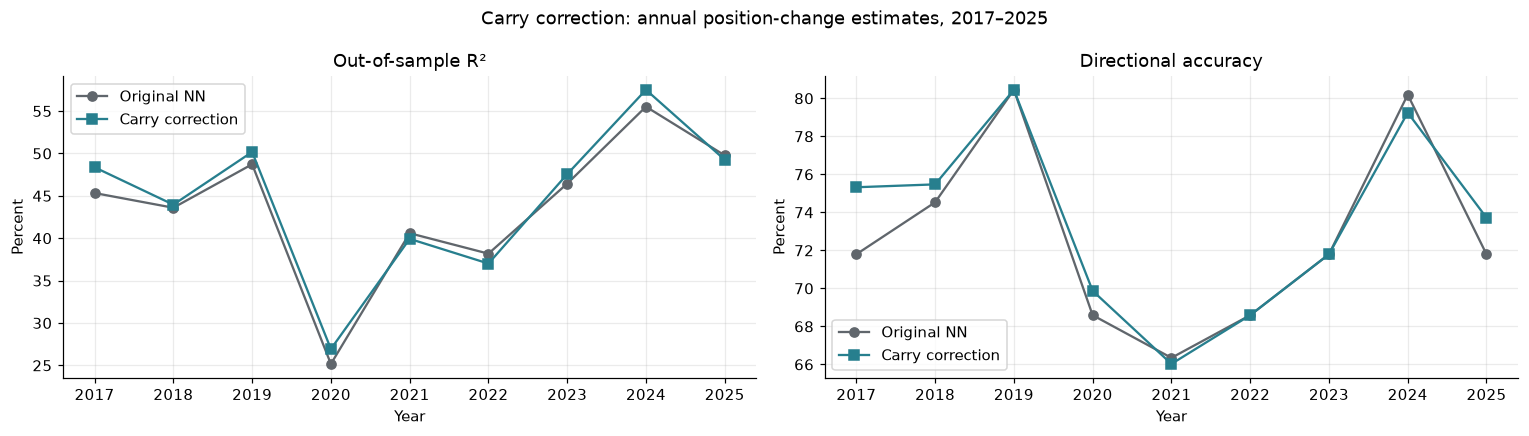

In [9]:
corrected, _ = carry_residual_head(baseline, carry_features, weeks)
display(paired_summary(corrected, baseline, 'Carry correction').drop(columns='Observations').round(2))
annual_comparison(corrected, baseline, 'Carry correction')

The correction reaches **46.02% R²**, adding 1.12 percentage points while leaving the original NN fixed. Six of nine years improve; 2021, 2022 and 2025 decline.

## 3. Volatility scaling

A given trend signal may support a smaller position when price volatility is high. Following the position-sizing idea in [Aspect Capital (2023)](https://aspectcapital.s3.amazonaws.com/documents/Aspect_Capital_Insight__Series_-_Trend_Following_-_How.pdf), we fit:

$$\hat y_{m,t}=b_{m,t}+\left(\frac{\nu^{ref}_{m,t}}{\nu_{m,t}}\right)^{\alpha}T_{m,t},\qquad 0\leq\alpha\leq1.$$

$\nu^{ref}$ is the market's median volatility over the preceding 104 weeks. We learn one shared $\alpha$ jointly with the NN; zero gives no scaling and one gives inverse-volatility scaling. The bias is not scaled. The volatility ratio and multiplier are not clipped. The learned exponent is our extension.

,R² (%),Direction (%),MAE (contracts),ΔR² (pp)
Original NN,44.90,72.7,10793.88,0.00
Risk scaling,47.27,73.3,10599.78,2.37


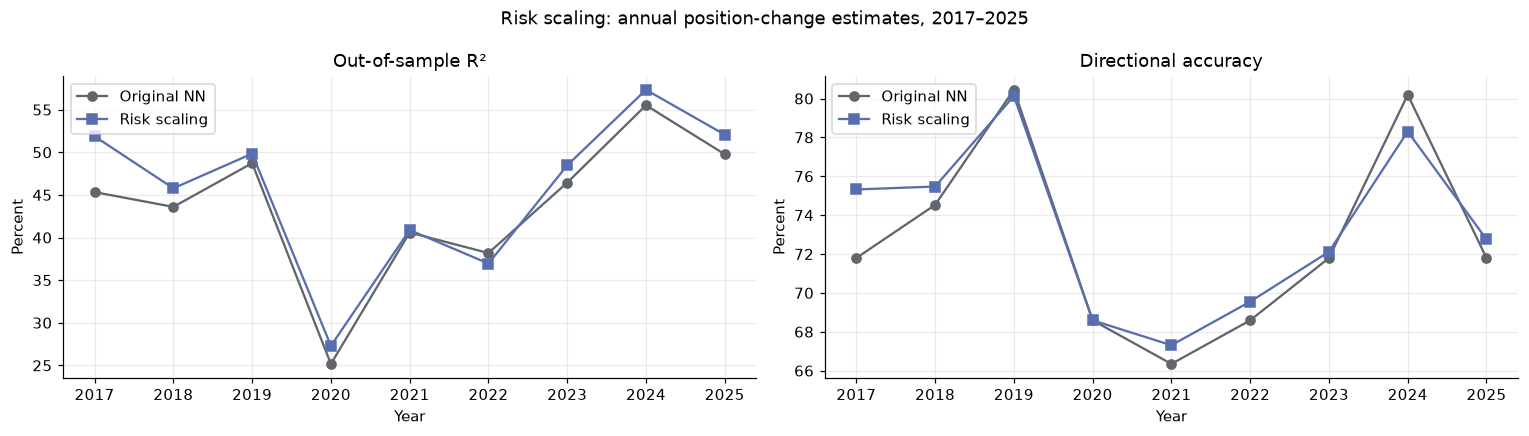

In [10]:
risk = run_extension('risk')
display(paired_summary(risk, baseline, 'Risk scaling').drop(columns='Observations').round(2))
annual_comparison(risk, baseline, 'Risk scaling')

In [11]:
risk_without_scaling = risk.assign(predicted_change=risk['gate_off_change'])
display(pd.DataFrame({
    'Risk scaling': score(common_sample(risk)),
    'Same fitted weights, multiplier = 1': score(common_sample(risk_without_scaling)),
}).T.drop(columns='Observations').round(2))

,R² (%),Direction (%),MAE (contracts)
Risk scaling,47.27,73.30,10599.78
"Same fitted weights, multiplier = 1",47.19,73.26,10605.53


R² reaches **47.27%**, up 2.37 percentage points, with gains in eight of nine years. The average $\alpha$ is only 0.019; setting the multiplier to one while keeping the fitted weights still gives **47.19% R²**.

## 4. Volatility scaling plus carry correction

Carry may still explain errors after the volatility model is fitted. We repeat the correction from Section 2 using this model's own past errors:

$$\widehat{\Delta MM}^{both}_{m,t}=\widehat{\Delta MM}^{risk}_{m,t}+s_{m,t}\gamma^{risk}_{m,t}\Delta z_{m,t}.$$

We compare the combined model with volatility scaling alone.

,R² (%),Direction (%),MAE (contracts),ΔR² (pp)
Risk scaling,47.27,73.30,10599.78,0.00
Risk + carry,48.40,73.55,10498.50,1.12


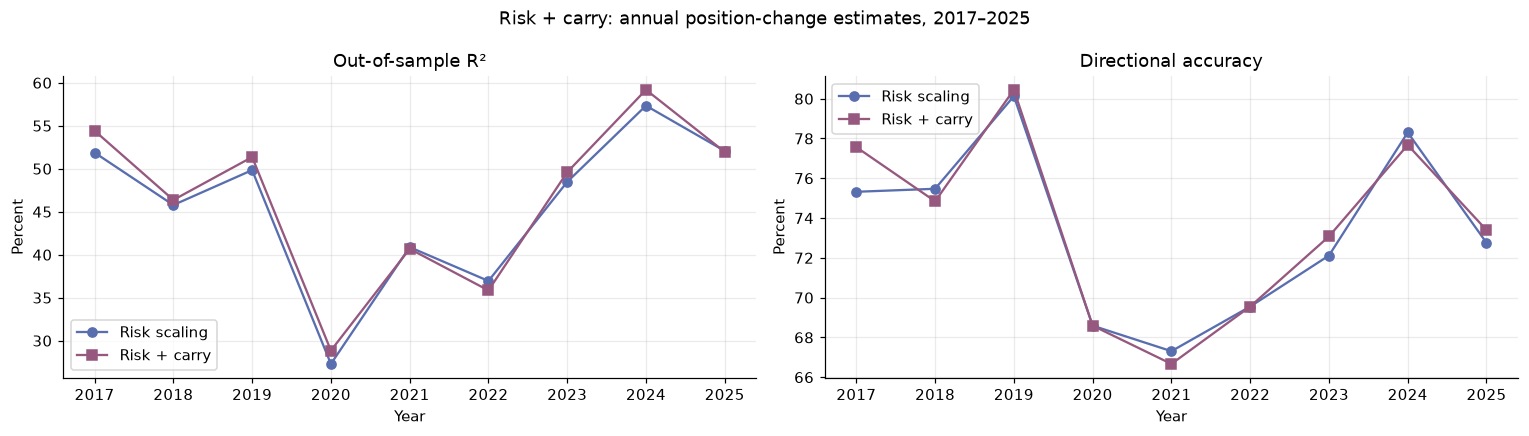

In [12]:
combined, _ = carry_residual_head(risk, carry_features, weeks)
display(paired_summary(combined, risk, 'Risk + carry', 'Risk scaling').drop(columns='Observations').round(2))
annual_comparison(combined, risk, 'Risk + carry', 'Risk scaling')

The combination reaches **48.40% R²**, adding 1.12 percentage points to volatility scaling alone. Carry raises full-period R² in all six markets, although its annual contribution is negative in 2021, 2022 and 2025.

## Results together

All rows use the same observations. Pooled R² gives more influence to markets with larger changes in contract units; the heatmap shows each market separately.

,R² (%),Direction (%),MAE (contracts),ΔR² vs NN (pp)
Original NN,44.90,72.70,10793.88,0.00
Direct carry,46.93,73.48,10635.00,2.03
Carry correction,46.02,73.40,10707.25,1.12
Risk scaling,47.27,73.30,10599.78,2.37
Risk + carry,48.40,73.55,10498.50,3.49


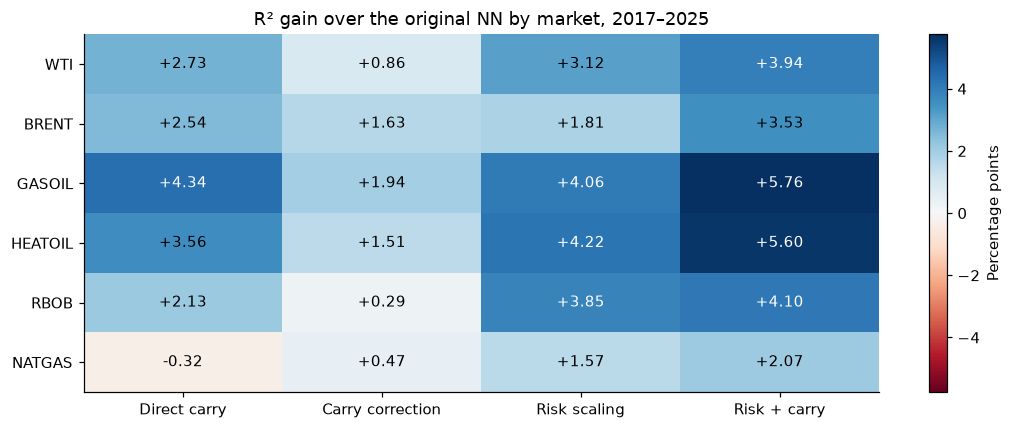

In [13]:
models = {'Original NN': baseline, 'Direct carry': direct, 'Carry correction': corrected,
          'Risk scaling': risk, 'Risk + carry': combined}
matched = {name: common_sample(frame).set_index(KEYS).sort_index() for name, frame in models.items()}
summary = pd.DataFrame({name: score(frame) for name, frame in matched.items()}).T
summary['ΔR² vs NN (pp)'] = summary['R² (%)'] - summary.loc['Original NN', 'R² (%)']
display(summary.drop(columns='Observations').round(2))

period_scores = pd.DataFrame({
    name: {period: score(frame.loc[frame['panel_date'].dt.year.between(lo, hi)])['R² (%)']
           for period, lo, hi in [('2017–2019', 2017, 2019), ('2020–2022', 2020, 2022), ('2023–2025', 2023, 2025)]}
    for name, frame in matched.items()})

market_scores = pd.DataFrame({name: {market: score(frame.xs(market, level='market'))['R² (%)']
                                    for market in MARKETS} for name, frame in matched.items()})
market_gains = market_scores.drop(columns='Original NN').sub(market_scores['Original NN'], axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
limit = max(1, np.abs(market_gains.to_numpy()).max())
im = ax.imshow(market_gains.to_numpy(), cmap='RdBu', vmin=-limit, vmax=limit, aspect='auto')
ax.set(xticks=range(4), xticklabels=market_gains.columns, yticks=range(6), yticklabels=market_gains.index,
       title='R² gain over the original NN by market, 2017–2025')
for i in range(6):
    for j in range(4):
        value = market_gains.iloc[i, j]
        ax.text(j, i, f'{value:+.2f}', ha='center', va='center',
                color='white' if abs(value) > .65 * limit else 'black')
fig.colorbar(im, ax=ax, label='Percentage points')
fig.tight_layout()
fig.savefig(OUTPUT / 'market_r2_gains.png', dpi=160)
plt.show()

## Next step

We will take forward volatility scaling plus carry correction, with volatility scaling alone as the comparison model. We will freeze the specification before testing an unused period.

This is a retrospective comparison, and most of the volatility model's gain remains when scaling is switched off after fitting, so the improvement also reflects the fitted network weights.

## Save results

In [14]:
for name, frame in models.items():
    frame.to_csv(OUTPUT / (name.lower().replace(' ', '_') + '_predictions.csv'), index=False)
summary.to_csv(OUTPUT / 'summary.csv')
period_scores.to_csv(OUTPUT / 'period_r2.csv')
market_scores.to_csv(OUTPUT / 'market_r2.csv')
pd.concat({name: annual_scores(frame) for name, frame in models.items()},
          names=['Model', 'Year']).to_csv(OUTPUT / 'annual_scores.csv')

## References

- Sun, Bouchouev and Fattouh (2026), [Momentum Trading and Managed Money Positioning in Energy](https://www.oxfordenergy.org/wpcms/wp-content/uploads/2026/03/Insight-177-Money-Positioning-in-Energy.pdf), OIES Insight 177, §§2–3.
- Koijen, Moskowitz, Pedersen and Vrugt (2018), [Carry](https://www.aqr.com/Insights/Research/Journal-Article/Carry), *Journal of Financial Economics* 127, §§2.3 and 3.2.
- Aspect Capital (2023), [Trend Following: How?](https://aspectcapital.s3.amazonaws.com/documents/Aspect_Capital_Insight__Series_-_Trend_Following_-_How.pdf), pp. 3 and 6.